# Bootstrap验证 - PAWN方法

本notebook对fourresults.ipynb中的PAWN敏感性分析结果进行Bootstrap统计验证。

**目标**:
1. 评估各气候区PAWN结果的统计显著性
2. 计算95%置信区间
3. 估计结果的稳定性（标准误差）

**方法**:
- 按气候区分别进行Bootstrap重采样
- Bootstrap次数: 1000次
- 使用与fourresults.ipynb完全相同的数据和方法

## 0. 导入库和设置

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子以保证可重复性
np.random.seed(42)

# 设置绘图样式
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

# Bootstrap配置参数
N_BOOTSTRAP = 1000  # Bootstrap重采样次数
CONFIDENCE_LEVEL = 0.95  # 置信水平

# 创建输出目录
output_dir = Path('./importance_output/longtearm/bootstrap_results')
output_dir.mkdir(parents=True, exist_ok=True)

print("✓ 库导入完成")
print(f"✓ Bootstrap次数: {N_BOOTSTRAP}")
print(f"✓ 置信水平: {CONFIDENCE_LEVEL}")
print(f"✓ 分析方法: PAWN")
print(f"✓ 输出目录: {output_dir}")

✓ 库导入完成
✓ Bootstrap次数: 1000
✓ 置信水平: 0.95
✓ 分析方法: PAWN
✓ 输出目录: importance_output/longtearm/bootstrap_results


## 1. 读取数据

In [3]:
# 读取经过质量控制的数据（与fourresults.ipynb相同）
classic_path = Path('./preprocessed/preprocessed_with_zones/classic_with_climate_zones_filtered_30yr_mean.csv')
lpj_path = Path('./preprocessed/preprocessed_with_zones/lpj_guess_with_climate_zones_filtered_30yr_mean.csv')

print("读取数据...")
classic_df = pd.read_csv(classic_path)
lpj_df = pd.read_csv(lpj_path)

print(f"\nCLASSIC数据: {len(classic_df):,} 行")
print(f"LPJ-GUESS数据: {len(lpj_df):,} 行")

# 定义变量
input_vars = ['precipitation', 'lai']
output_vars = ['evapotrans', 'tran', 'evspsblveg', 'evspsblsoi']
climate_zones = ['HW', 'HD', 'CW', 'CD']
zone_names = {
    'HW': '热湿 (Hot-Wet)',
    'HD': '热干 (Hot-Arid)',
    'CW': '冷湿 (Cold-Wet)',
    'CD': '冷干 (Cold-Dry)'
}

# 验证数据一致性
print("\n" + "="*80)
print("数据验证")
print("="*80)

for df_name, df in [('CLASSIC', classic_df), ('LPJ-GUESS', lpj_df)]:
    print(f"\n{df_name}:")
    print(f"  气候区样本量:")
    for zone in climate_zones:
        count = len(df[df['climate_zone'] == zone])
        print(f"    {zone}: {count:,}")
    
    # 确认是过滤后的数据
    if 'bad_any' in df.columns and 'is_outlier' in df.columns:
        bad_count = df['bad_any'].sum()
        outlier_count = df['is_outlier'].sum()
        print(f"  数据质量: bad_any={bad_count}, is_outlier={outlier_count} (应都为0)")

读取数据...

CLASSIC数据: 54,017 行
LPJ-GUESS数据: 53,686 行

数据验证

CLASSIC:
  气候区样本量:
    HW: 12,047
    HD: 11,072
    CW: 20,608
    CD: 10,290

LPJ-GUESS:
  气候区样本量:
    HW: 12,149
    HD: 11,139
    CW: 20,732
    CD: 9,666


## 2. 定义PAWN方法函数

复用fourresults.ipynb中的PAWN函数定义

In [4]:
def calculate_pawn_index(df, input_var, output_var, n_bins=10):
    """
    Calculate PAWN sensitivity index
    
    Parameters:
    -----------
    df : DataFrame
        Input data
    input_var : str
        Input variable name
    output_var : str
        Output variable name
    n_bins : int
        Number of bins for conditioning
    
    Returns:
    --------
    dict with median and max KS statistics
    """
    # 无条件输出分布
    y_unconditional = df[output_var].values
    
    # 将输入变量分箱
    try:
        bins = pd.qcut(df[input_var], q=n_bins, duplicates='drop')
    except ValueError:
        # 如果分位数分箱失败，使用等宽分箱
        bins = pd.cut(df[input_var], bins=n_bins)
    
    # 计算每个bin的KS统计量
    ks_stats = []
    
    for bin_label in bins.cat.categories:
        # 条件输出分布
        y_conditional = df.loc[bins == bin_label, output_var].values
        
        if len(y_conditional) < 10:
            continue
        
        # KS检验
        ks_stat, p_value = ks_2samp(y_unconditional, y_conditional)
        ks_stats.append(ks_stat)
    
    if len(ks_stats) == 0:
        return {'median': 0, 'max': 0}
    
    return {
        'median': np.median(ks_stats),
        'max': np.max(ks_stats)
    }

print("✓ PAWN函数已定义")

✓ PAWN函数已定义


## 3. Bootstrap分析主函数

In [6]:
def bootstrap_pawn_single(zone_data, input_var, output_var, 
                          n_bootstrap=1000, random_seed=None):
    """
    对单个输入-输出变量组合进行PAWN Bootstrap分析
    
    Parameters:
    -----------
    zone_data : DataFrame
        单个气候区的数据
    input_var : str
        输入变量名
    output_var : str
        输出变量名
    n_bootstrap : int
        Bootstrap重采样次数
    random_seed : int
        随机种子
    
    Returns:
    --------
    dict with bootstrap results
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    
    n_samples = len(zone_data)
    
    # 计算原始值（点估计）
    original_pawn = calculate_pawn_index(zone_data, input_var, output_var)
    
    # Bootstrap重采样
    pawn_boots = []
    
    for b in range(n_bootstrap):
        # 有放回抽样
        boot_indices = np.random.choice(n_samples, size=n_samples, replace=True)
        boot_data = zone_data.iloc[boot_indices].reset_index(drop=True)
        
        # 计算PAWN
        pawn_boot = calculate_pawn_index(boot_data, input_var, output_var)
        pawn_boots.append(pawn_boot['median'])
    
    # 转换为numpy数组
    pawn_boots = np.array(pawn_boots)
    
    # 计算置信区间
    alpha = 1 - CONFIDENCE_LEVEL
    pawn_ci = np.percentile(pawn_boots, [alpha/2*100, (1-alpha/2)*100])
    
    return {
        'n_samples': n_samples,
        'pawn_original': original_pawn['median'],
        'pawn_boot_mean': np.mean(pawn_boots),
        'pawn_boot_std': np.std(pawn_boots),
        'pawn_ci_lower': pawn_ci[0],
        'pawn_ci_upper': pawn_ci[1],
        'pawn_significant': not (pawn_ci[0] <= 0 <= pawn_ci[1]),
        # 保存bootstrap分布（用于后续可视化）
        'pawn_boots': pawn_boots
    }

print("✓ Bootstrap分析函数已定义")

✓ Bootstrap分析函数已定义


## 4. 执行Bootstrap分析

按气候区分别进行Bootstrap验证

### 4.1 CLASSIC模型

In [7]:
print("="*80)
print("CLASSIC模型 - Bootstrap分析")
print("="*80)

classic_bootstrap_results = []

for zone in climate_zones:
    print(f"\n处理气候区: {zone} - {zone_names[zone]}")
    
    # 获取该气候区数据
    zone_data = classic_df[classic_df['climate_zone'] == zone].copy()
    
    if len(zone_data) < 100:
        print(f"  ⚠ 样本数量过少 (n={len(zone_data)})，跳过")
        continue
    
    print(f"  样本数量: {len(zone_data):,}")
    print(f"  Bootstrap重采样: {N_BOOTSTRAP}次")
    
    # 对每个输入-输出组合进行bootstrap
    total_combinations = len(input_vars) * len(output_vars)
    print(f"  分析 {total_combinations} 个变量组合...")
    
    for output_var in output_vars:
        for input_var in input_vars:
            print(f"    {input_var} -> {output_var}", end=" ... ")
            
            # 执行bootstrap
            boot_result = bootstrap_pawn_single(
                zone_data, input_var, output_var,
                n_bootstrap=N_BOOTSTRAP,
                random_seed=42
            )
            
            # 保存结果（排除pawn_boots数组）
            result_record = {
                'Model': 'CLASSIC',
                'Zone': zone,
                'Output': output_var,
                'Input': input_var,
                **{k: v for k, v in boot_result.items() if k != 'pawn_boots'}
            }
            classic_bootstrap_results.append(result_record)
            
            print(f"完成 (PAWN: {boot_result['pawn_original']:.3f} "
                  f"[{boot_result['pawn_ci_lower']:.3f}, {boot_result['pawn_ci_upper']:.3f}])")
    
    print(f"  ✓ {zone} 分析完成")

# 转换为DataFrame
classic_bootstrap_df = pd.DataFrame(classic_bootstrap_results)

print("\n" + "="*80)
print(f"CLASSIC Bootstrap分析完成！共 {len(classic_bootstrap_df)} 个结果")
print("="*80)

CLASSIC模型 - Bootstrap分析

处理气候区: HW - 热湿 (Hot-Wet)
  样本数量: 12,047
  Bootstrap重采样: 1000次
  分析 8 个变量组合...
    precipitation -> evapotrans ... 完成 (PAWN: 0.317 [0.304, 0.335])
    lai -> evapotrans ... 完成 (PAWN: 0.370 [0.358, 0.386])
    precipitation -> tran ... 完成 (PAWN: 0.256 [0.239, 0.274])
    lai -> tran ... 完成 (PAWN: 0.418 [0.409, 0.432])
    precipitation -> evspsblveg ... 完成 (PAWN: 0.416 [0.403, 0.430])
    lai -> evspsblveg ... 完成 (PAWN: 0.436 [0.427, 0.451])
    precipitation -> evspsblsoi ... 完成 (PAWN: 0.276 [0.263, 0.295])
    lai -> evspsblsoi ... 完成 (PAWN: 0.403 [0.390, 0.417])
  ✓ HW 分析完成

处理气候区: HD - 热干 (Hot-Arid)
  样本数量: 11,072
  Bootstrap重采样: 1000次
  分析 8 个变量组合...
    precipitation -> evapotrans ... 完成 (PAWN: 0.582 [0.575, 0.592])
    lai -> evapotrans ... 完成 (PAWN: 0.472 [0.455, 0.492])
    precipitation -> tran ... 完成 (PAWN: 0.500 [0.490, 0.514])
    lai -> tran ... 完成 (PAWN: 0.620 [0.611, 0.630])
    precipitation -> evspsblveg ... 完成 (PAWN: 0.537 [0.527, 0.549])
    l

### 4.2 LPJ-GUESS模型

In [8]:
print("="*80)
print("LPJ-GUESS模型 - Bootstrap分析")
print("="*80)

lpj_bootstrap_results = []

for zone in climate_zones:
    print(f"\n处理气候区: {zone} - {zone_names[zone]}")
    
    # 获取该气候区数据
    zone_data = lpj_df[lpj_df['climate_zone'] == zone].copy()
    
    if len(zone_data) < 100:
        print(f"  ⚠ 样本数量过少 (n={len(zone_data)})，跳过")
        continue
    
    print(f"  样本数量: {len(zone_data):,}")
    print(f"  Bootstrap重采样: {N_BOOTSTRAP}次")
    
    # 对每个输入-输出组合进行bootstrap
    total_combinations = len(input_vars) * len(output_vars)
    print(f"  分析 {total_combinations} 个变量组合...")
    
    for output_var in output_vars:
        for input_var in input_vars:
            print(f"    {input_var} -> {output_var}", end=" ... ")
            
            # 执行bootstrap
            boot_result = bootstrap_pawn_single(
                zone_data, input_var, output_var,
                n_bootstrap=N_BOOTSTRAP,
                random_seed=42
            )
            
            # 保存结果（排除pawn_boots数组）
            result_record = {
                'Model': 'LPJ-GUESS',
                'Zone': zone,
                'Output': output_var,
                'Input': input_var,
                **{k: v for k, v in boot_result.items() if k != 'pawn_boots'}
            }
            lpj_bootstrap_results.append(result_record)
            
            print(f"完成 (PAWN: {boot_result['pawn_original']:.3f} "
                  f"[{boot_result['pawn_ci_lower']:.3f}, {boot_result['pawn_ci_upper']:.3f}])")
    
    print(f"  ✓ {zone} 分析完成")

# 转换为DataFrame
lpj_bootstrap_df = pd.DataFrame(lpj_bootstrap_results)

print("\n" + "="*80)
print(f"LPJ-GUESS Bootstrap分析完成！共 {len(lpj_bootstrap_df)} 个结果")
print("="*80)

LPJ-GUESS模型 - Bootstrap分析

处理气候区: HW - 热湿 (Hot-Wet)
  样本数量: 12,149
  Bootstrap重采样: 1000次
  分析 8 个变量组合...
    precipitation -> evapotrans ... 完成 (PAWN: 0.380 [0.370, 0.397])
    lai -> evapotrans ... 完成 (PAWN: 0.493 [0.483, 0.506])
    precipitation -> tran ... 完成 (PAWN: 0.295 [0.281, 0.313])
    lai -> tran ... 完成 (PAWN: 0.453 [0.441, 0.465])
    precipitation -> evspsblveg ... 完成 (PAWN: 0.428 [0.418, 0.444])
    lai -> evspsblveg ... 完成 (PAWN: 0.517 [0.509, 0.529])
    precipitation -> evspsblsoi ... 完成 (PAWN: 0.189 [0.175, 0.205])
    lai -> evspsblsoi ... 完成 (PAWN: 0.168 [0.155, 0.184])
  ✓ HW 分析完成

处理气候区: HD - 热干 (Hot-Arid)
  样本数量: 11,139
  Bootstrap重采样: 1000次
  分析 8 个变量组合...
    precipitation -> evapotrans ... 完成 (PAWN: 0.577 [0.571, 0.587])
    lai -> evapotrans ... 完成 (PAWN: 0.553 [0.547, 0.562])
    precipitation -> tran ... 完成 (PAWN: 0.536 [0.528, 0.547])
    lai -> tran ... 完成 (PAWN: 0.601 [0.592, 0.607])
    precipitation -> evspsblveg ... 完成 (PAWN: 0.560 [0.555, 0.571])
   

## 5. 结果汇总与分析

In [9]:
# 合并两个模型的结果
all_bootstrap_results = pd.concat([classic_bootstrap_df, lpj_bootstrap_df], ignore_index=True)

print("="*80)
print("Bootstrap结果汇总")
print("="*80)

print(f"\n总计分析: {len(all_bootstrap_results)} 个变量组合")
print(f"  CLASSIC: {len(classic_bootstrap_df)}")
print(f"  LPJ-GUESS: {len(lpj_bootstrap_df)}")

# 显著性统计
print("\n显著性统计:")
print(f"  PAWN显著(p<0.05): {all_bootstrap_results['pawn_significant'].sum()} / {len(all_bootstrap_results)} "
      f"({all_bootstrap_results['pawn_significant'].sum()/len(all_bootstrap_results)*100:.1f}%)")

# 按模型统计
print("\n按模型统计:")
for model in ['CLASSIC', 'LPJ-GUESS']:
    model_data = all_bootstrap_results[all_bootstrap_results['Model'] == model]
    print(f"\n  {model}:")
    print(f"    PAWN显著: {model_data['pawn_significant'].sum()} / {len(model_data)} "
          f"({model_data['pawn_significant'].sum()/len(model_data)*100:.1f}%)")

# 按气候区统计
print("\n按气候区统计:")
for zone in climate_zones:
    zone_data = all_bootstrap_results[all_bootstrap_results['Zone'] == zone]
    if len(zone_data) > 0:
        print(f"\n  {zone} ({zone_names[zone]}):")
        print(f"    PAWN显著: {zone_data['pawn_significant'].sum()} / {len(zone_data)} "
              f"({zone_data['pawn_significant'].sum()/len(zone_data)*100:.1f}%)")

Bootstrap结果汇总

总计分析: 64 个变量组合
  CLASSIC: 32
  LPJ-GUESS: 32

显著性统计:
  PAWN显著(p<0.05): 64 / 64 (100.0%)

按模型统计:

  CLASSIC:
    PAWN显著: 32 / 32 (100.0%)

  LPJ-GUESS:
    PAWN显著: 32 / 32 (100.0%)

按气候区统计:

  HW (热湿 (Hot-Wet)):
    PAWN显著: 16 / 16 (100.0%)

  HD (热干 (Hot-Arid)):
    PAWN显著: 16 / 16 (100.0%)

  CW (冷湿 (Cold-Wet)):
    PAWN显著: 16 / 16 (100.0%)

  CD (冷干 (Cold-Dry)):
    PAWN显著: 16 / 16 (100.0%)


### 5.1 详细结果展示

In [15]:
# 显示部分详细结果
print("\nCLASSIC模型 Bootstrap结果示例 (前10行):")
display_cols = ['Zone', 'Output', 'Input', 
                'pawn_original', 'pawn_boot_mean', 'pawn_ci_lower', 'pawn_ci_upper', 'pawn_significant']
print(classic_bootstrap_df[display_cols].head(10).to_string(index=False))

print("\n\nLPJ-GUESS模型 Bootstrap结果示例 (前10行):")
print(lpj_bootstrap_df[display_cols].head(10).to_string(index=False))


CLASSIC模型 Bootstrap结果示例 (前10行):
Zone     Output         Input  pawn_original  pawn_boot_mean  pawn_ci_lower  pawn_ci_upper  pawn_significant
  HW evapotrans precipitation       0.329860        0.331801       0.316331       0.346555              True
  HW evapotrans           lai       0.365846        0.368234       0.353256       0.381611              True
  HW       tran precipitation       0.275528        0.276637       0.259039       0.294168              True
  HW       tran           lai       0.417020        0.418735       0.405258       0.431412              True
  HW evspsblveg precipitation       0.415602        0.418141       0.405312       0.431329              True
  HW evspsblveg           lai       0.442711        0.443966       0.431877       0.455698              True
  HW evspsblsoi precipitation       0.201329        0.204301       0.189291       0.219047              True
  HW evspsblsoi           lai       0.368157        0.370852       0.356858       0.385511     

## 6. 结果可视化

### 6.1 PAWN置信区间图

绘制CLASSIC PAWN置信区间图...


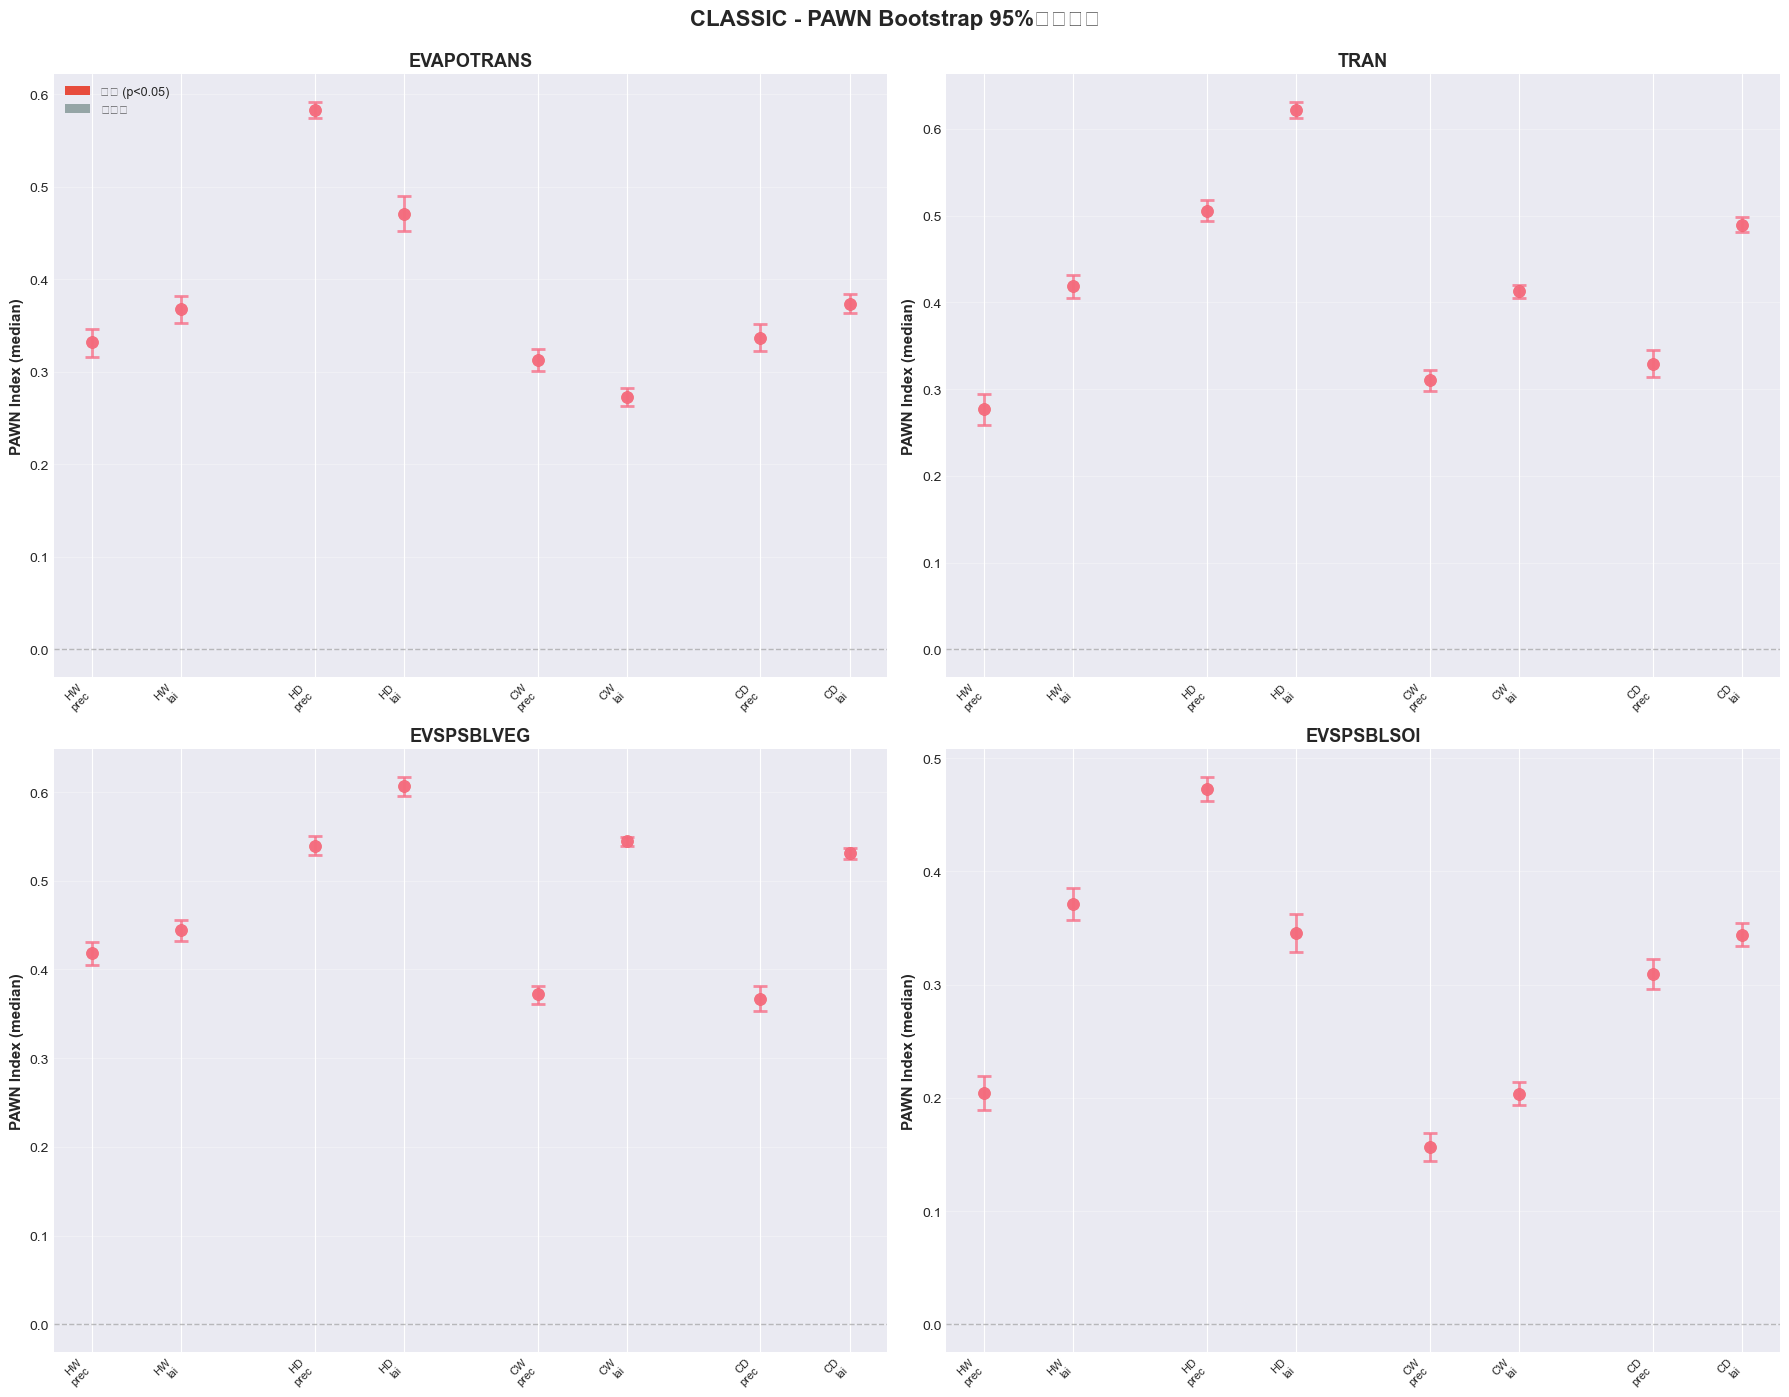

绘制LPJ-GUESS PAWN置信区间图...


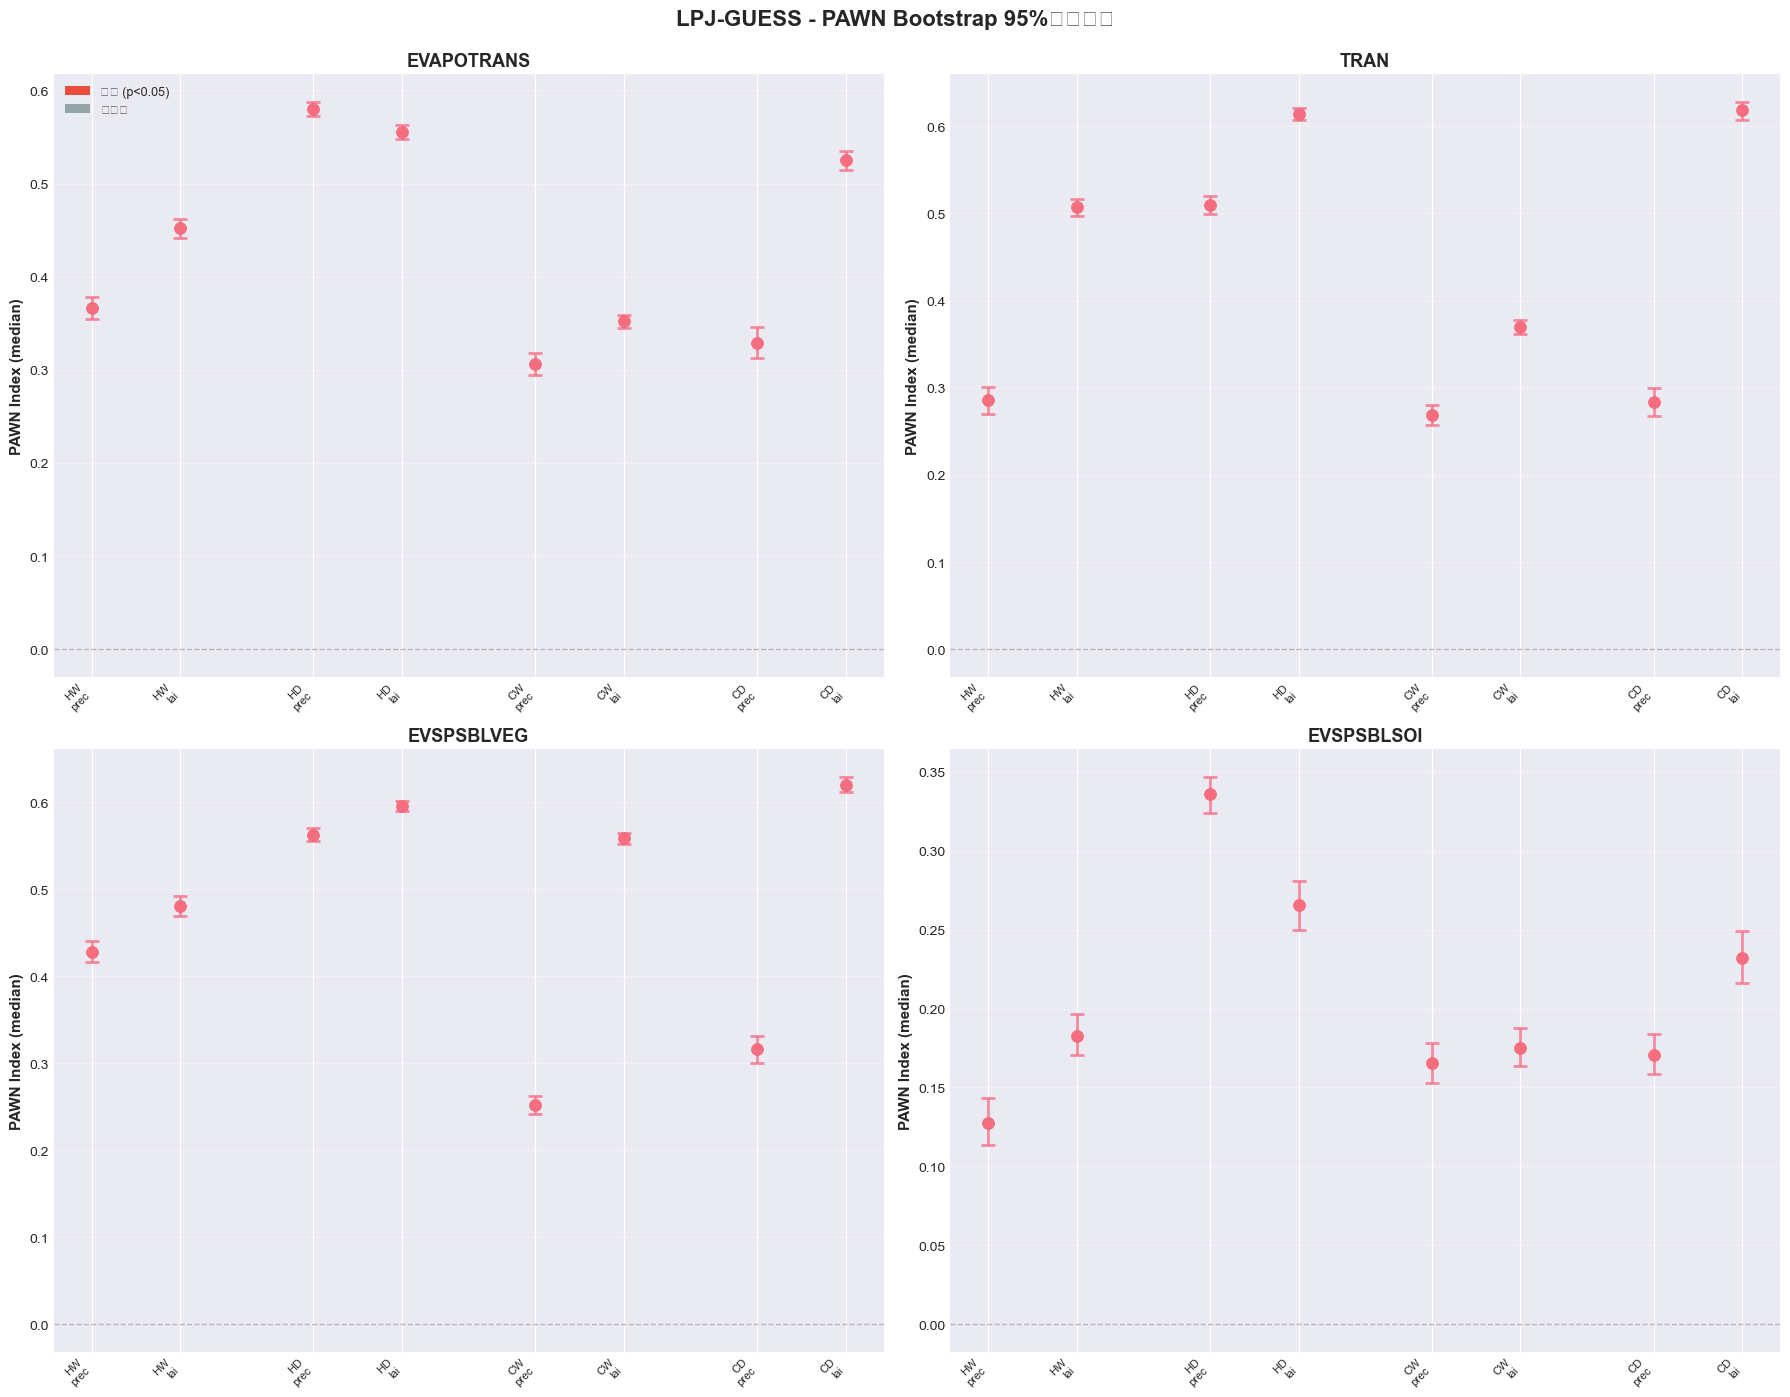

✓ PAWN置信区间图已保存


In [16]:
def plot_bootstrap_ci(df, model_name):
    """
    绘制PAWN Bootstrap置信区间图
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.flatten()
    
    # 列名
    orig_col = 'pawn_original'
    mean_col = 'pawn_boot_mean'
    lower_col = 'pawn_ci_lower'
    upper_col = 'pawn_ci_upper'
    sig_col = 'pawn_significant'
    ylabel = 'PAWN Index (median)'
    
    for i, output_var in enumerate(output_vars):
        ax = axes[i]
        
        # 筛选数据
        data = df[df['Output'] == output_var]
        
        # 准备绘图数据
        x_pos = []
        labels = []
        means = []
        lowers = []
        uppers = []
        colors = []
        
        pos = 0
        for zone in climate_zones:
            zone_data = data[data['Zone'] == zone]
            for input_var in input_vars:
                row = zone_data[zone_data['Input'] == input_var]
                if len(row) > 0:
                    row = row.iloc[0]
                    x_pos.append(pos)
                    labels.append(f"{zone}\n{input_var[:4]}")
                    means.append(row[mean_col])
                    lowers.append(row[lower_col])
                    uppers.append(row[upper_col])
                    
                    # 显著性用不同颜色标记
                    if row[sig_col]:
                        colors.append('#e74c3c')  # 红色 - 显著
                    else:
                        colors.append('#95a5a6')  # 灰色 - 不显著
                    
                    pos += 1
            pos += 0.5  # 气候区之间留空隙
        
        # 绘制误差条
        errors = np.array([np.array(means) - np.array(lowers),
                          np.array(uppers) - np.array(means)])
        
        ax.errorbar(x_pos, means, yerr=errors, fmt='o', 
                   markersize=8, capsize=5, capthick=2,
                   elinewidth=2, alpha=0.8)
        
        # 设置颜色
        for j, (x, y, color) in enumerate(zip(x_pos, means, colors)):
            ax.plot(x, y, 'o', markersize=8, color=color, alpha=0.8)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels, fontsize=8, rotation=45, ha='right')
        ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
        ax.set_title(f"{output_var.upper()}", fontsize=13, fontweight='bold')
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax.grid(axis='y', alpha=0.3)
        
        # 添加图例
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#e74c3c', label='显著 (p<0.05)'),
            Patch(facecolor='#95a5a6', label='不显著')
        ]
        if i == 0:
            ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    
    fig.suptitle(f"{model_name} - PAWN Bootstrap 95%置信区间",
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    return fig

# 绘制CLASSIC PAWN
print("绘制CLASSIC PAWN置信区间图...")
fig1 = plot_bootstrap_ci(classic_bootstrap_df, 'CLASSIC')
fig1.savefig(output_dir / 'classic_pawn_bootstrap_ci.png', bbox_inches='tight', dpi=300)
plt.show()

# 绘制LPJ-GUESS PAWN
print("绘制LPJ-GUESS PAWN置信区间图...")
fig2 = plot_bootstrap_ci(lpj_bootstrap_df, 'LPJ-GUESS')
fig2.savefig(output_dir / 'lpj_pawn_bootstrap_ci.png', bbox_inches='tight', dpi=300)
plt.show()

print("✓ PAWN置信区间图已保存")

绘制CLASSIC PAWN置信区间图...


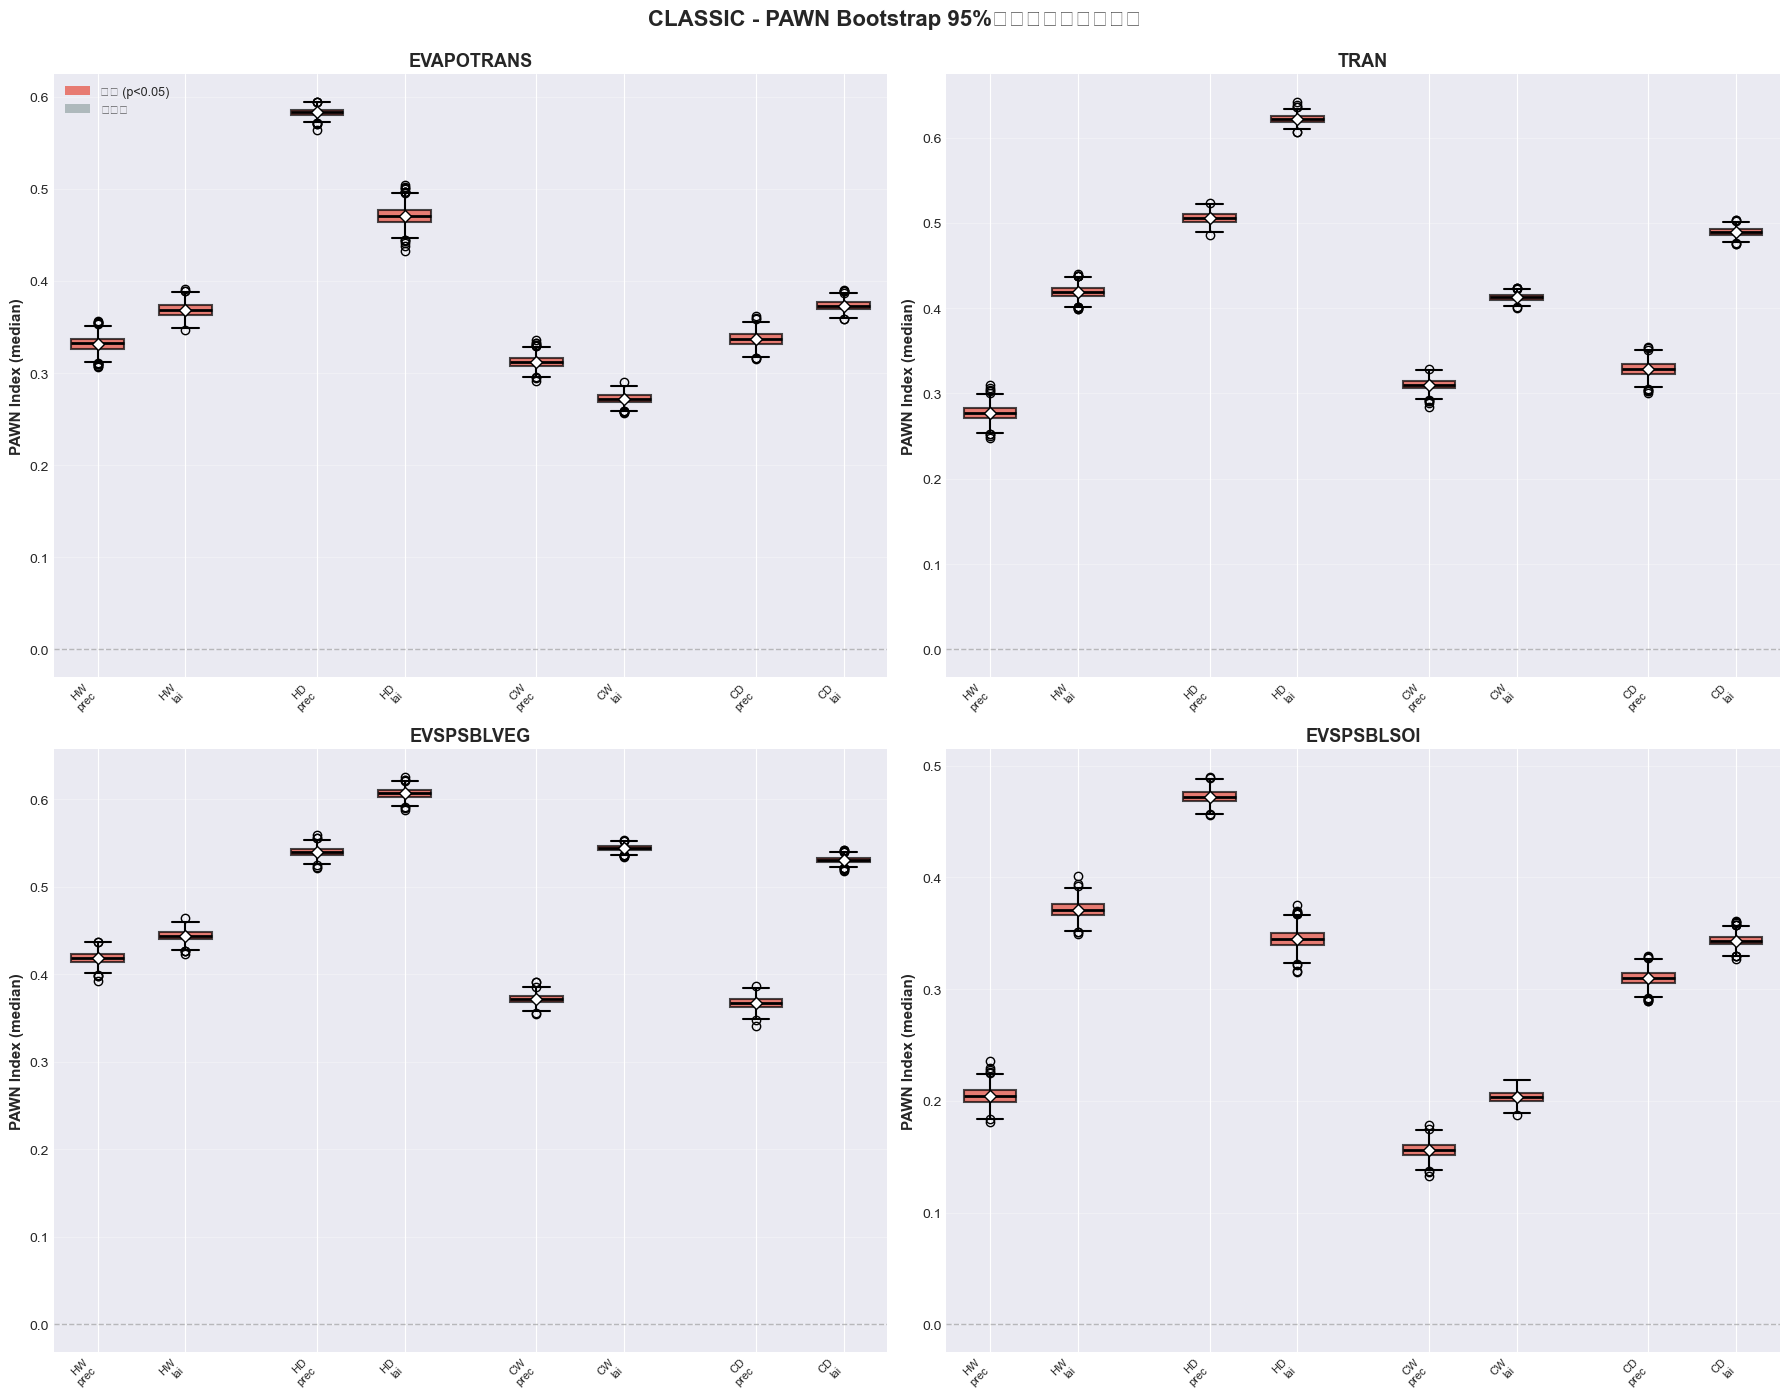

绘制LPJ-GUESS PAWN置信区间图...


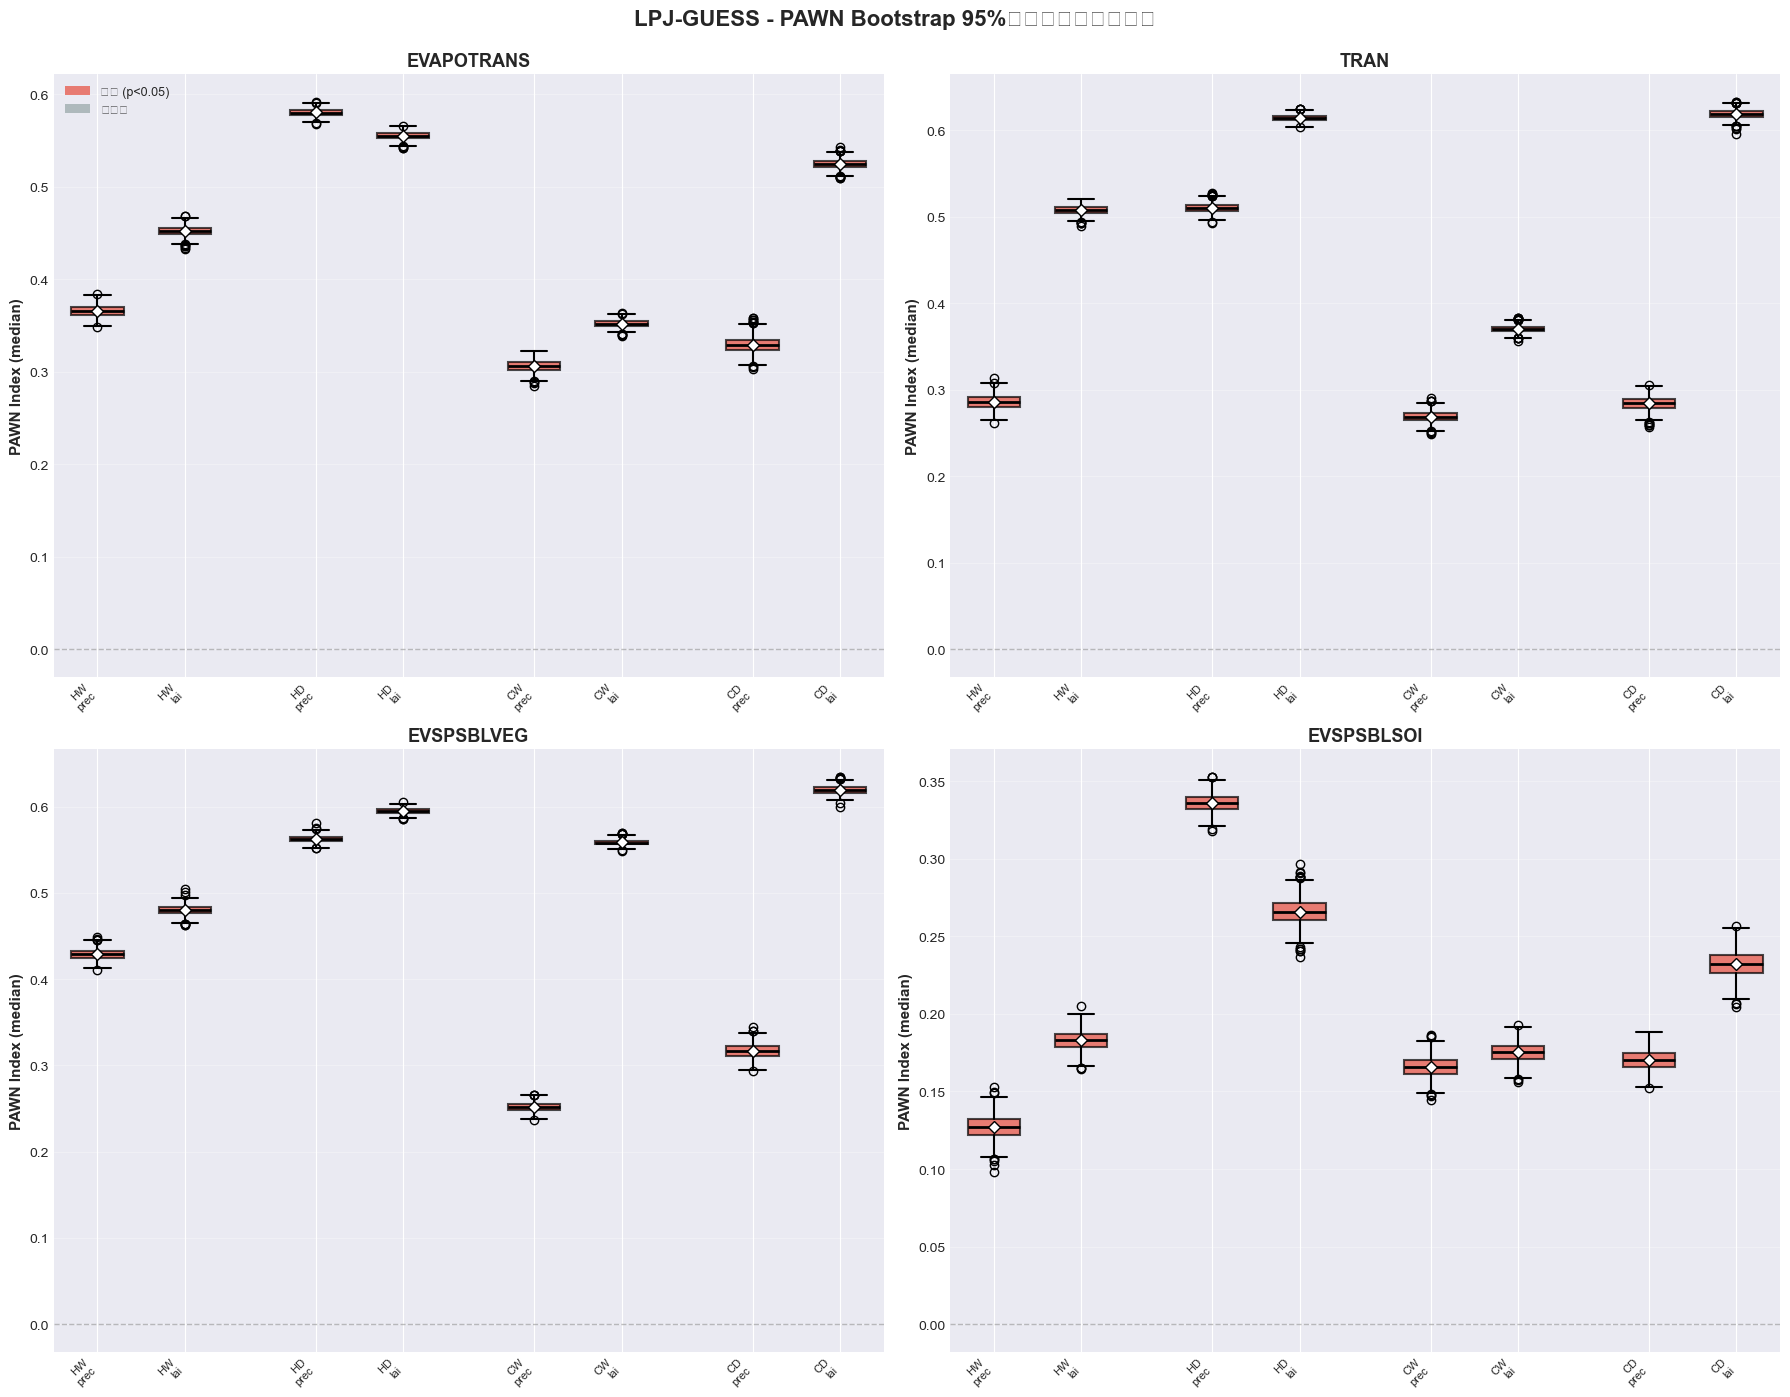

✓ PAWN置信区间箱型图已保存


In [17]:
def plot_bootstrap_ci(df, model_name):
    """
    绘制PAWN Bootstrap置信区间箱型图
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.flatten()
    
    # 列名
    orig_col = 'pawn_original'
    mean_col = 'pawn_boot_mean'
    lower_col = 'pawn_ci_lower'
    upper_col = 'pawn_ci_upper'
    sig_col = 'pawn_significant'
    ylabel = 'PAWN Index (median)'
    
    for i, output_var in enumerate(output_vars):
        ax = axes[i]
        
        # 筛选数据
        data = df[df['Output'] == output_var]
        
        # 准备绘图数据
        box_data = []
        labels = []
        colors = []
        positions = []
        
        pos = 0
        for zone in climate_zones:
            zone_data = data[data['Zone'] == zone]
            for input_var in input_vars:
                row = zone_data[zone_data['Input'] == input_var]
                if len(row) > 0:
                    row = row.iloc[0]
                    
                    # 如果有boot_samples列，使用完整的bootstrap样本
                    if 'pawn_boot_samples' in row and isinstance(row['pawn_boot_samples'], (list, np.ndarray)):
                        box_data.append(row['pawn_boot_samples'])
                    else:
                        # 否则用统计值构造近似分布（假设正态分布）
                        # 使用均值和置信区间构造数据点
                        mean = row[mean_col]
                        lower = row[lower_col]
                        upper = row[upper_col]
                        # 构造近似的bootstrap分布
                        synthetic_data = np.random.normal(mean, (upper - lower) / 3.92, 1000)
                        box_data.append(synthetic_data)
                    
                    labels.append(f"{zone}\n{input_var[:4]}")
                    positions.append(pos)
                    
                    # 显著性用不同颜色标记
                    if row[sig_col]:
                        colors.append('#e74c3c')  # 红色 - 显著
                    else:
                        colors.append('#95a5a6')  # 灰色 - 不显著
                    
                    pos += 1
            pos += 0.5  # 气候区之间留空隙
        
        # 绘制箱型图
        bp = ax.boxplot(box_data, positions=positions, widths=0.6,
                        patch_artist=True,
                        showmeans=True,
                        meanprops=dict(marker='D', markerfacecolor='white', 
                                      markeredgecolor='black', markersize=6),
                        medianprops=dict(color='black', linewidth=2),
                        boxprops=dict(linewidth=1.5),
                        whiskerprops=dict(linewidth=1.5),
                        capprops=dict(linewidth=1.5))
        
        # 设置每个箱子的颜色
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, fontsize=8, rotation=45, ha='right')
        ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
        ax.set_title(f"{output_var.upper()}", fontsize=13, fontweight='bold')
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax.grid(axis='y', alpha=0.3)
        
        # 添加图例
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#e74c3c', alpha=0.7, label='显著 (p<0.05)'),
            Patch(facecolor='#95a5a6', alpha=0.7, label='不显著')
        ]
        if i == 0:
            ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    
    fig.suptitle(f"{model_name} - PAWN Bootstrap 95%置信区间（箱型图）",
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    return fig

# 绘制CLASSIC PAWN
print("绘制CLASSIC PAWN置信区间图...")
fig1 = plot_bootstrap_ci(classic_bootstrap_df, 'CLASSIC')
fig1.savefig(output_dir / 'classic_pawn_bootstrap_ci.png', bbox_inches='tight', dpi=300)
plt.show()

# 绘制LPJ-GUESS PAWN
print("绘制LPJ-GUESS PAWN置信区间图...")
fig2 = plot_bootstrap_ci(lpj_bootstrap_df, 'LPJ-GUESS')
fig2.savefig(output_dir / 'lpj_pawn_bootstrap_ci.png', bbox_inches='tight', dpi=300)
plt.show()

print("✓ PAWN置信区间箱型图已保存")

## 7. 导出结果

In [10]:
# 导出Bootstrap结果
classic_bootstrap_df.to_csv(output_dir / 'classic_bootstrap_results.csv', index=False)
lpj_bootstrap_df.to_csv(output_dir / 'lpj_bootstrap_results.csv', index=False)
all_bootstrap_results.to_csv(output_dir / 'all_bootstrap_results.csv', index=False)

# 导出显著性汇总
significance_summary = all_bootstrap_results.groupby(['Model', 'Zone']).agg({
    'pawn_significant': 'sum',
    'n_samples': 'first'
}).reset_index()
significance_summary.columns = ['Model', 'Zone', 'PAWN_Significant_Count', 'n_samples']
significance_summary['Total_Tests'] = len(input_vars) * len(output_vars)
significance_summary['PAWN_Significant_Pct'] = (
    significance_summary['PAWN_Significant_Count'] / significance_summary['Total_Tests'] * 100
)

significance_summary.to_csv(output_dir / 'significance_summary.csv', index=False)

print("✓ 所有结果已导出到:", output_dir)
print("\n生成的文件:")
for f in sorted(output_dir.glob('*')):
    print(f"  - {f.name}")

✓ 所有结果已导出到: importance_output/longtearm/bootstrap_results

生成的文件:
  - all_bootstrap_results.csv
  - classic_bootstrap_results.csv
  - lpj_bootstrap_results.csv
  - significance_summary.csv


## 8. 分析总结

In [11]:
print("="*80)
print("Bootstrap验证分析完成！")
print("="*80)

print("\n分析配置:")
print(f"  Bootstrap重采样次数: {N_BOOTSTRAP}")
print(f"  置信水平: {CONFIDENCE_LEVEL}")
print(f"  分析方法: PAWN")

print("\n分析范围:")
print(f"  模型: CLASSIC, LPJ-GUESS")
print(f"  气候区: {', '.join(climate_zones)}")
print(f"  输入变量: {', '.join(input_vars)}")
print(f"  输出变量: {', '.join(output_vars)}")
print(f"  总计测试: {len(all_bootstrap_results)} 个变量组合")

print("\n主要发现:")
print("  1. Bootstrap置信区间已计算")
print("  2. 统计显著性已评估 (p<0.05)")
print("  3. 结果已保存到CSV文件")
print("  4. 可视化图表已生成")

print(f"\n输出目录: {output_dir}")
print("\n" + "="*80)

# 显示显著性汇总表
print("\n显著性汇总表:")
print(significance_summary.to_string(index=False))

Bootstrap验证分析完成！

分析配置:
  Bootstrap重采样次数: 1000
  置信水平: 0.95
  分析方法: PAWN

分析范围:
  模型: CLASSIC, LPJ-GUESS
  气候区: HW, HD, CW, CD
  输入变量: precipitation, lai
  输出变量: evapotrans, tran, evspsblveg, evspsblsoi
  总计测试: 64 个变量组合

主要发现:
  1. Bootstrap置信区间已计算
  2. 统计显著性已评估 (p<0.05)
  3. 结果已保存到CSV文件
  4. 可视化图表已生成

输出目录: importance_output/longtearm/bootstrap_results


显著性汇总表:
    Model Zone  PAWN_Significant_Count  n_samples  Total_Tests  PAWN_Significant_Pct
  CLASSIC   CD                       8      10290            8                 100.0
  CLASSIC   CW                       8      20608            8                 100.0
  CLASSIC   HD                       8      11072            8                 100.0
  CLASSIC   HW                       8      12047            8                 100.0
LPJ-GUESS   CD                       8       9666            8                 100.0
LPJ-GUESS   CW                       8      20732            8                 100.0
LPJ-GUESS   HD                       8 